In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.tsa.stattools
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [7]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/datasets/Horizon Retail Supply.csv",
    usecols=['date', 'sales'],
    index_col="date",
    parse_dates=["date"]
)

df = df.resample('ME').sum(numeric_only=True)
df.head(3)

,sales
date,
2013-01-31,454904
2013-02-28,459417
2013-03-31,617382


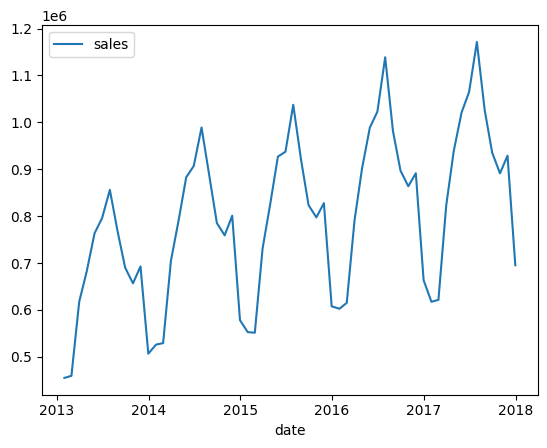

In [8]:
import seaborn as sns

sns.lineplot(df);

In [11]:
e, p = stats.shapiro(df)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9821346440635419
p-valor: 0.5251891157186783


In [12]:
df_log = np.log(df)

e, p = stats.shapiro(df_log)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9648742062916836
p-valor: 0.08164839921284583


In [13]:
df_cube = np.sign(df)*abs(df)**(1/3)

e, p = stats.shapiro(df_cube)
print('Estatística de teste: {}'.format(e))
print('p-valor: {}'.format(p))

Estatística de teste: 0.9735313743715098
p-valor: 0.21648348913616772


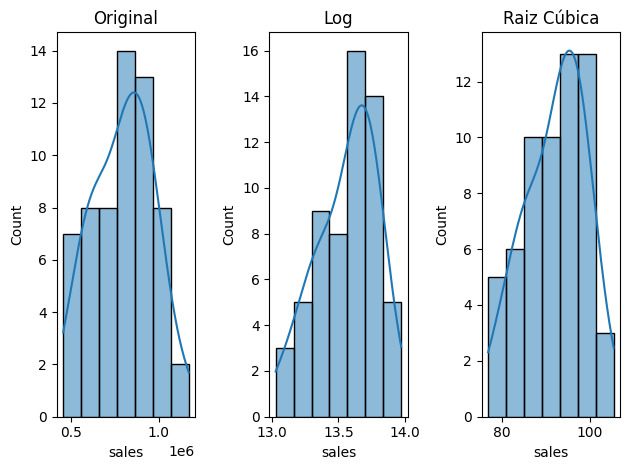

In [15]:
series = [df, df_log, df_cube]
titles = ["Original", "Log", "Raiz Cúbica"]

fig, axes = plt.subplots(1, 3)

for ax, data, title in zip(axes, series, titles):
    sns.histplot(data["sales"], ax=ax, kde=True)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [17]:
adf_result = statsmodels.tsa.stattools.adfuller(df_log, autolag='AIC')
print('ADF Test: Ruído Branco')
print('Estatística do teste: {:.4f}'.format(adf_result[0]))
print('p-valor: {:.4f}'.format(adf_result[1]))
print('Valores Críticos:')
for chave, valor in adf_result[4].items():
    print('{}: {:.4f}'.format(chave, valor))
print('Resultado:')
if adf_result[1] <= 0.05:
    print("Rejeitar a hipótese nula (H0): Os dados são estacionários.")
else:
    print("Falha ao rejeitar a hipótese nula (H0): Os dados não são estacionários.")
print('\n')

ADF Test: Ruído Branco
Estatística do teste: -7.0235
p-valor: 0.0000
Valores Críticos:
1%: -3.5746
5%: -2.9240
10%: -2.6000
Resultado:
Rejeitar a hipótese nula (H0): Os dados são estacionários.




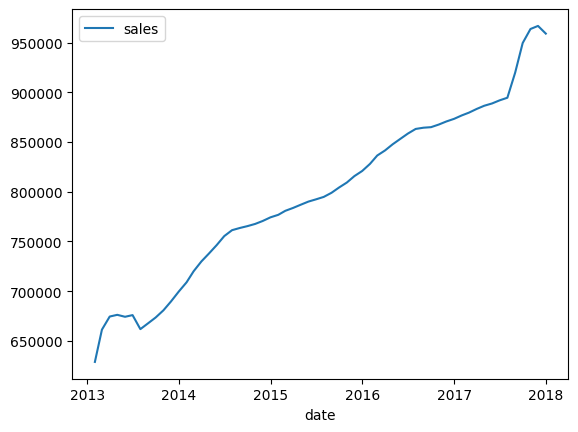

In [18]:
tendencia = df.rolling(window=12, center=True, min_periods=1).mean()
sns.lineplot(tendencia);

In [23]:
sarima_model = SARIMAX(df,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -567.751
Date:                           Fri, 20 Mar 2026   AIC                           1145.501
Time:                                   14:39:51   BIC                           1154.307
Sample:                               01-31-2013   HQIC                          1148.749
                                    - 12-31-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0970      0.726     -0.134      0.894      -1.520       1.326
ma.L1          0.8899      0.200      4.445

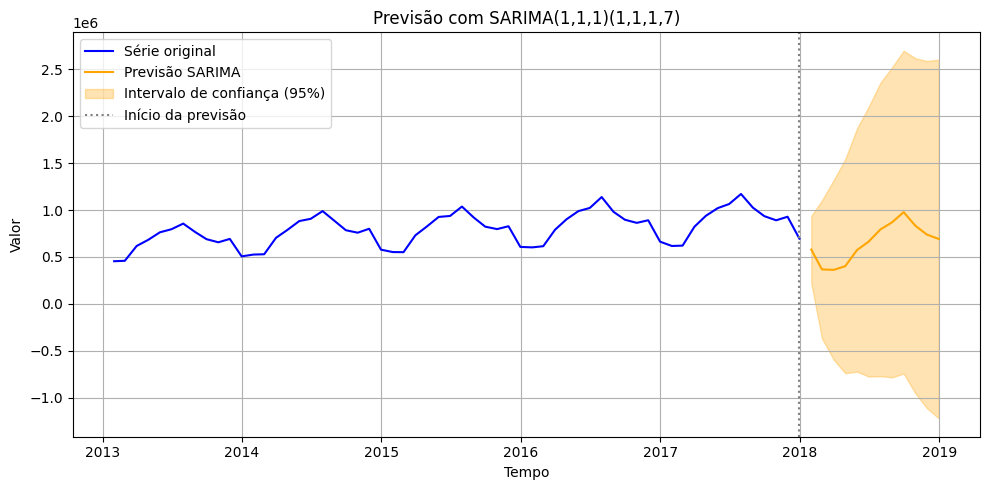

In [25]:
n_forecast = 12
forecast_res = sarima_fit.get_forecast(steps=n_forecast)

forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_index = pd.date_range(start=df.index[-1] + pd.offsets.MonthEnd(1),
                               periods=n_forecast, freq='ME')
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

plt.figure(figsize=(10,5))
plt.plot(df, label='Série original', color='blue')

plt.plot(forecast_mean, label='Previsão SARIMA', color='orange')

plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color='orange', alpha=0.3, label='Intervalo de confiança (95%)')

plt.axvline(x=df.index[-1], color='gray', linestyle=':', label='Início da previsão')

plt.title('Previsão com SARIMA(1,1,1)(1,1,1,7)')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()